# Performance Reporting: The Core Metric Set

**Docker image**: `ml4t`

This notebook turns a fully specified event-driven backtest into an auditable performance report.
It uses the RSI strategy and execution contract from `04_single_asset_ml4t_backtest`, then adds a
protocol-matched benchmark, exposure evidence, closed-trade diagnostics, and implementation-cost
accounting.

**Learning objectives**:

- Bridge keyed backtest returns to `PortfolioAnalysis` with crypto annualization
- Compare gross, net, and benchmark performance under matched execution assumptions
- Separate portfolio-level, closed-trade, exposure, and implementation-cost evidence
- Render the standard return, drawdown, rolling-risk, seasonality, and tail diagnostics

**Book reference**: Chapter 16, Section 16.5 (Performance Metrics and Reporting)

**Prerequisite**: `04_single_asset_ml4t_backtest`

## Setup

In [1]:
"""Build an auditable performance report from protocol-matched BTC backtests."""

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import BacktestConfig, DataFeed, Engine, ExecutionMode, Strategy
from ml4t.backtest.analytics import MAEMFEAnalyzer, TradeAnalyzer
from ml4t.backtest.config import ExecutionPrice, ShareType
from ml4t.diagnostic.integration import portfolio_analysis_from_result
from ml4t.diagnostic.visualization import add_annotation
from ml4t.diagnostic.visualization.portfolio import (
    plot_cumulative_returns,
    plot_drawdown_underwater,
    plot_monthly_returns_heatmap,
    plot_rolling_sharpe,
)

from data import load_crypto_perps
from utils.style import COLORS, ml4t_diverging

In [2]:
# Production defaults - Papermill injects overrides after this cell
START_DATE = "2020-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 100_000
FEES = 0.001  # 10 bps per fill
SLIPPAGE = 0.0005  # 5 bps per fill
RSI_PERIOD = 14
RSI_LOWER = 30
RSI_UPPER = 70
POSITION_SIZE = 0.95
N_BARS = 0  # 0 uses the full date range; a positive value keeps the latest bars

In [3]:
display(
    Markdown(
        f"The experiment uses a **{RSI_PERIOD}-day simple rolling RSI**, enters below "
        f"**{RSI_LOWER}**, exits above **{RSI_UPPER}**, and targets **{POSITION_SIZE:.0%}** "
        f"exposure. Net fills pay **{FEES:.2%} commission** plus **{SLIPPAGE:.2%} slippage**."
    )
)

The experiment uses a **14-day simple rolling RSI**, enters below **30**, exits above **70**, and targets **95%** exposure. Net fills pay **0.10% commission** plus **0.05% slippage**.

## 1. Reproduce the Signed Backtest Protocol

The strategy is deliberately unchanged from `04_single_asset_ml4t_backtest`. Its RSI is a simple
rolling mean of gains and losses. The first valid value therefore appears only after the complete
warmup window. A close-derived signal is submitted after the UTC day closes and fills at the next
UTC day's open.

### RSI indicator

In [4]:
def compute_rsi(close: pl.Series, period: int = 14) -> pl.Series:
    """Compute RSI from simple rolling mean gains and losses."""
    delta = close.diff()
    gain = delta.clip(lower_bound=0.0)
    loss = (-delta).clip(lower_bound=0.0)
    avg_gain = gain.rolling_mean(window_size=period, min_samples=period)
    avg_loss = loss.rolling_mean(window_size=period, min_samples=period)

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

### RSI strategy

Target weights express the allocation rule directly. Fractional sizing avoids the integer-unit
truncation that is especially material for a high-priced asset such as BTC.

In [5]:
class RSIMeanReversionStrategy(Strategy):
    """Long-only RSI threshold strategy."""

    def __init__(
        self,
        rsi_lower: float = 30,
        rsi_upper: float = 70,
        position_size: float = 0.95,
    ):
        self.rsi_lower = rsi_lower
        self.rsi_upper = rsi_upper
        self.position_size = position_size

    def on_data(self, timestamp, data, context, broker):
        """Submit target-weight orders from the close-based RSI state."""
        rsi = context.get("rsi")
        if rsi is None or np.isnan(rsi):
            return

        asset = "BTCUSDT"
        if data.get(asset) is None:
            return

        position = broker.get_position(asset)
        is_in_position = position is not None and position.quantity > 0

        if not is_in_position and rsi < self.rsi_lower:
            broker.order_target_percent(asset, self.position_size)
        elif is_in_position and rsi > self.rsi_upper:
            broker.order_target_percent(asset, 0.0)

### Protocol-matched benchmark

Buy-and-hold uses the same sample, engine, 95% signal-time target, next-open execution,
fractional units, crypto calendar, and costs. It changes only the trading rule.

In [6]:
class BuyAndHoldStrategy(Strategy):
    """Submit one target-weight entry and retain it through the sample."""

    def __init__(self, position_size: float = 0.95):
        self.position_size = position_size
        self.submitted = False

    def on_data(self, timestamp, data, context, broker):
        """Submit the benchmark entry on the first available bar."""
        asset = "BTCUSDT"
        if not self.submitted and data.get(asset) is not None:
            broker.order_target_percent(asset, self.position_size)
            self.submitted = True

### Canonical daily bars and indicator context

BTC perpetual data arrive as hourly bars. Aggregation into UTC days preserves the canonical
`symbol` and `timestamp` keys and validates the OHLC contract before any signal is computed.

In [7]:
_crypto = load_crypto_perps(
    symbols=["BTCUSDT"],
    start_date=START_DATE,
    end_date=END_DATE,
)
prices_df = (
    _crypto.filter(
        (pl.col("symbol") == "BTCUSDT")
        & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
        & (pl.col("timestamp") < pl.lit(END_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
    )
    .sort("timestamp")
    .with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    .group_by_dynamic("timestamp", every="1d", group_by="symbol")
    .agg(
        pl.col("open").first(),
        pl.col("high").max(),
        pl.col("low").min(),
        pl.col("close").last(),
        pl.col("volume").sum(),
    )
    .sort(["symbol", "timestamp"])
)
if N_BARS > 0:
    prices_df = prices_df.tail(N_BARS)

price_columns = ["open", "high", "low", "close"]
assert prices_df.n_unique(["symbol", "timestamp"]) == len(prices_df)
assert prices_df["symbol"].unique().to_list() == ["BTCUSDT"]
assert prices_df.select(pl.col(price_columns).is_not_null().all()).row(0) == (True,) * 4
assert prices_df.select((pl.col(price_columns) > 0).all()).row(0) == (True,) * 4
assert prices_df.select((pl.col("high") >= pl.max_horizontal("open", "close", "low")).all()).item()
assert prices_df.select((pl.col("low") <= pl.min_horizontal("open", "close", "high")).all()).item()
assert len(prices_df) > RSI_PERIOD

print(f"Loaded {len(prices_df):,} unique BTC UTC-day bars")

Loaded 1,461 unique BTC UTC-day bars


In [8]:
rsi_values = compute_rsi(prices_df["close"], RSI_PERIOD)
context_df = prices_df.select("timestamp").with_columns(rsi_values.alias("rsi"))
rsi_valid = context_df["rsi"].drop_nulls().drop_nans()

assert len(rsi_valid) <= len(context_df) - RSI_PERIOD
assert rsi_valid.is_between(0, 100, closed="both").all()
print(f"RSI warmup leaves {len(rsi_valid):,} valid observations from {len(context_df):,} bars")

RSI warmup leaves 1,447 valid observations from 1,461 bars


### Gross, net, and benchmark runs

Gross and net strategy runs share signals and timing. The gross run removes modeled costs; the net
run and benchmark both include them. `ShareType.FRACTIONAL`, `calendar="crypto"`, and
`ExecutionMode.NEXT_BAR` make the sizing, annualization, and fill convention explicit.

In [9]:
config_gross = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    execution_price=ExecutionPrice.OPEN,
    commission_rate=0.0,
    slippage_rate=0.0,
    share_type=ShareType.FRACTIONAL,
    calendar="crypto",
)
config_net = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    execution_price=ExecutionPrice.OPEN,
    commission_rate=FEES,
    slippage_rate=SLIPPAGE,
    share_type=ShareType.FRACTIONAL,
    calendar="crypto",
)

In [10]:
strategy_parameters = {
    "rsi_lower": RSI_LOWER,
    "rsi_upper": RSI_UPPER,
    "position_size": POSITION_SIZE,
}
results_gross = Engine(
    feed=DataFeed(prices_df=prices_df, context_df=context_df),
    strategy=RSIMeanReversionStrategy(**strategy_parameters),
    config=config_gross,
).run()
results_net = Engine(
    feed=DataFeed(prices_df=prices_df, context_df=context_df),
    strategy=RSIMeanReversionStrategy(**strategy_parameters),
    config=config_net,
).run()
benchmark_results = Engine(
    feed=DataFeed(prices_df=prices_df),
    strategy=BuyAndHoldStrategy(position_size=POSITION_SIZE),
    config=config_net,
).run()

assert results_gross.equity is not None and results_gross.equity.periods_per_year == 365
assert results_net.equity is not None and results_net.equity.periods_per_year == 365
assert benchmark_results.equity is not None and benchmark_results.equity.periods_per_year == 365
assert all(fill.asset == "BTCUSDT" for fill in results_net.fills)
assert all(fill.price_source == "open" for fill in results_net.fills)
assert len(benchmark_results.fills) == 1
assert len(benchmark_results.trades) == 1
assert benchmark_results.trades[0].status == "open"

In [11]:
run_summary = pl.DataFrame(
    {
        "run": ["RSI gross", "RSI net", "Buy and hold net"],
        "final_value_usdt": [
            float(results_gross["final_value"]),
            float(results_net["final_value"]),
            float(benchmark_results["final_value"]),
        ],
        "total_return_pct": [
            float(results_gross["total_return_pct"]),
            float(results_net["total_return_pct"]),
            float(benchmark_results["total_return_pct"]),
        ],
        "fills": [
            len(results_gross.fills),
            len(results_net.fills),
            len(benchmark_results.fills),
        ],
    }
).with_columns(pl.col(["final_value_usdt", "total_return_pct"]).round(2))
display(run_summary)

run,final_value_usdt,total_return_pct,fills
str,f64,f64,i64
"""RSI gross""",88857.43,-11.14,28
"""RSI net""",74528.29,-25.47,28
"""Buy and hold net""",563355.67,463.36,1


## 2. Join Daily Returns by Date

A tear sheet is only meaningful when strategy and benchmark observations refer to the same dates.
Each result first becomes a keyed daily frame. One-to-one joins then establish alignment before any
array crosses the `PortfolioAnalysis` API boundary. This avoids silently pairing unrelated rows.

In [12]:
def daily_return_frame(result, column_name: str) -> pl.DataFrame:
    """Return a unique, sorted calendar-day return frame."""
    frame = (
        result.to_daily_pnl(session_aligned=False)
        .select(pl.col("date"), pl.col("return_pct").alias(column_name))
        .sort("date")
    )
    assert frame.n_unique("date") == len(frame)
    return frame

In [13]:
daily_returns = (
    daily_return_frame(results_gross, "gross_return")
    .join(daily_return_frame(results_net, "net_return"), on="date", how="inner", validate="1:1")
    .join(
        daily_return_frame(benchmark_results, "benchmark_return"),
        on="date",
        how="inner",
        validate="1:1",
    )
)

assert len(daily_returns) == len(results_net.to_daily_pnl(session_aligned=False))
assert daily_returns.select(pl.all().is_not_null().all()).row(0) == (True,) * 4

analysis_gross = portfolio_analysis_from_result(results_gross, calendar="crypto")
analysis_net = portfolio_analysis_from_result(
    results_net,
    calendar="crypto",
    benchmark=daily_returns["benchmark_return"],
)
analysis_benchmark = portfolio_analysis_from_result(benchmark_results, calendar="crypto")

assert analysis_net.dates.to_list() == daily_returns["date"].to_list()
assert np.allclose(analysis_gross.returns, daily_returns["gross_return"], rtol=0, atol=1e-12)
assert np.allclose(analysis_net.returns, daily_returns["net_return"], rtol=0, atol=1e-12)
assert np.allclose(
    analysis_benchmark.returns,
    daily_returns["benchmark_return"],
    rtol=0,
    atol=1e-12,
)

elapsed_days = (daily_returns["date"].max() - daily_returns["date"].min()).days
elapsed_years = elapsed_days / 365.0
assert elapsed_years > 0
print(
    f"Aligned {len(daily_returns):,} crypto daily returns from "
    f"{daily_returns['date'].min()} to {daily_returns['date'].max()}"
)

Aligned 1,461 crypto daily returns from 2020-01-01 to 2023-12-31


Daily return and risk statistics use 365 observations per year, the `crypto` calendar convention.
Activity rates use the elapsed interval between the first and last keyed observations. Keeping
those two quantities separate avoids an off-by-one year estimate from dividing row count by 365.

## 3. Return, Risk, and Benchmark Metrics

In [14]:
metrics_gross = analysis_gross.compute_summary_stats()
metrics_net = analysis_net.compute_summary_stats()
metrics_benchmark = analysis_benchmark.compute_summary_stats()
dd_result = analysis_net.compute_drawdown_analysis()
dist = analysis_net.compute_returns_distribution()

The first table preserves exact reference values. The benchmark-relative columns come from the
date-aligned return vectors above and describe this sample, not a sealed holdout.

In [15]:
performance_table = pl.DataFrame(
    {
        "metric": [
            "Total return",
            "Annual return",
            "Annual volatility",
            "Sharpe ratio",
            "Sortino ratio",
            "Maximum drawdown",
            "Calmar ratio",
        ],
        "rsi_gross": [
            metrics_gross.total_return,
            metrics_gross.annual_return,
            metrics_gross.annual_volatility,
            metrics_gross.sharpe_ratio,
            metrics_gross.sortino_ratio,
            metrics_gross.max_drawdown,
            metrics_gross.calmar_ratio,
        ],
        "rsi_net": [
            metrics_net.total_return,
            metrics_net.annual_return,
            metrics_net.annual_volatility,
            metrics_net.sharpe_ratio,
            metrics_net.sortino_ratio,
            metrics_net.max_drawdown,
            metrics_net.calmar_ratio,
        ],
        "buy_hold_net": [
            metrics_benchmark.total_return,
            metrics_benchmark.annual_return,
            metrics_benchmark.annual_volatility,
            metrics_benchmark.sharpe_ratio,
            metrics_benchmark.sortino_ratio,
            metrics_benchmark.max_drawdown,
            metrics_benchmark.calmar_ratio,
        ],
    }
).with_columns(pl.col(["rsi_gross", "rsi_net", "buy_hold_net"]).round(4))

**Portfolio performance under the matched protocol:**

In [16]:
display(performance_table)

metric,rsi_gross,rsi_net,buy_hold_net
str,f64,f64,f64
"""Total return""",-0.1114,-0.2547,4.6336
"""Annual return""",-0.0291,-0.0708,0.5402
"""Annual volatility""",0.4696,0.4678,0.6659
"""Sharpe ratio""",0.1847,0.0899,0.9904
"""Sortino ratio""",0.1179,0.0573,1.0002
"""Maximum drawdown""",-0.6296,-0.6591,-0.7625
"""Calmar ratio""",-0.0462,-0.1074,0.7084


In [17]:
benchmark_metrics = pl.DataFrame(
    {
        "metric": ["Annual alpha", "Beta", "Information ratio"],
        "rsi_net_vs_buy_hold": [
            metrics_net.alpha,
            metrics_net.beta,
            metrics_net.information_ratio,
        ],
    }
).with_columns(pl.col("rsi_net_vs_buy_hold").round(4))
display(benchmark_metrics)

metric,rsi_net_vs_buy_hold
str,f64
"""Annual alpha""",-0.2967
"""Beta""",0.5137
"""Information ratio""",-1.3579


In [18]:
rsi_total_return = metrics_net.total_return
benchmark_total_return = metrics_benchmark.total_return
return_leader = "Buy-and-hold" if benchmark_total_return > rsi_total_return else "The RSI strategy"
display(
    Markdown(
        f"**{return_leader}** leads this protocol-matched in-sample comparison. The RSI strategy "
        f"returns **{rsi_total_return:.2%}** net versus **{benchmark_total_return:.2%}** for "
        f"buy-and-hold, with beta **{metrics_net.beta:.2f}** relative to the benchmark. Beta here "
        "measures participation in BTC's daily return path; it is not proof of independent alpha."
    )
)

**Buy-and-hold** leads this protocol-matched in-sample comparison. The RSI strategy returns **-25.47%** net versus **463.36%** for buy-and-hold, with beta **0.51** relative to the benchmark. Beta here measures participation in BTC's daily return path; it is not proof of independent alpha.

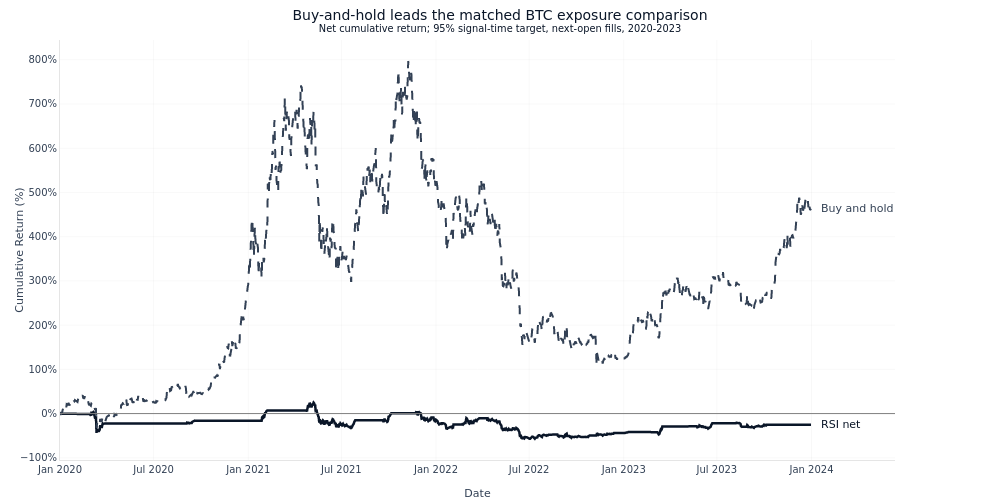

In [19]:
fig = plot_cumulative_returns(
    analysis_net,
    benchmark_label="Buy and hold",
    show_benchmark=True,
    log_scale=False,
)
fig.data[0].name = "RSI net"
fig.data[1].name = "Buy and hold"
fig.data[0].line.color = COLORS["blue"]
fig.data[1].line.color = COLORS["neutral"]
for trace in fig.data:
    add_annotation(
        fig,
        text=trace.name,
        x=trace.x[-1],
        y=trace.y[-1],
        xref="x",
        yref="y",
        xshift=8,
        xanchor="left",
        yanchor="middle",
        font={"color": trace.line.color, "size": 11},
    )
fig.update_layout(
    title=(
        f"{return_leader} leads the matched BTC exposure comparison"
        "<br><sup>Net cumulative return; 95% signal-time target, next-open fills, 2020-2023</sup>"
    ),
    yaxis_title="Cumulative Return (%)",
    height=500,
    margin={"r": 105},
)
fig.show()

## 4. Exposure Evidence

Portfolio state records make exposure observable rather than assumed. Gross exposure is the
absolute position value; net exposure is signed. They coincide for this long-only strategy but
would diverge for a long-short portfolio. Both are scaled by contemporaneous equity.

In [20]:
exposure_df = (
    results_net.to_portfolio_state_dataframe()
    .with_columns(
        gross_exposure_pct=pl.col("gross_exposure") / pl.col("equity"),
        net_exposure_pct=pl.col("net_exposure") / pl.col("equity"),
    )
    .sort("timestamp")
)
assert len(exposure_df) == len(prices_df)
assert exposure_df.select(pl.col("equity").is_finite().all()).item()
assert np.allclose(
    exposure_df["gross_exposure_pct"],
    exposure_df["net_exposure_pct"],
    rtol=0,
    atol=1e-12,
)

exposure_summary = pl.DataFrame(
    {
        "metric": [
            "Mean gross exposure",
            "Mean net exposure",
            "Maximum gross exposure",
            "Time invested",
        ],
        "value": [
            exposure_df["gross_exposure_pct"].mean(),
            exposure_df["net_exposure_pct"].mean(),
            exposure_df["gross_exposure_pct"].max(),
            (exposure_df["gross_exposure_pct"] > 1e-12).mean(),
        ],
    }
).with_columns(pl.col("value").round(4))
display(exposure_summary)

metric,value
str,f64
"""Mean gross exposure""",0.4056
"""Mean net exposure""",0.4056
"""Maximum gross exposure""",0.962
"""Time invested""",0.4305


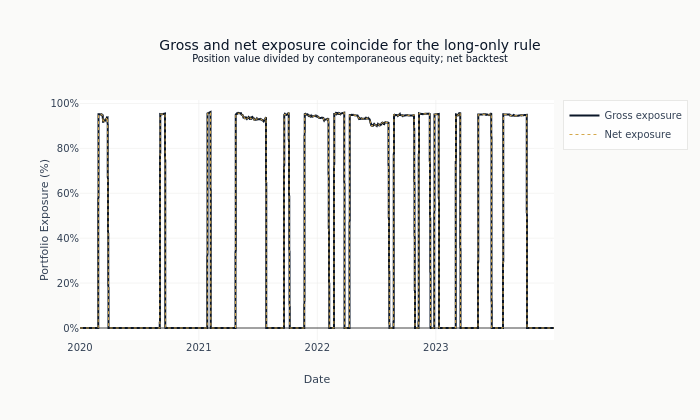

In [21]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=exposure_df["timestamp"].to_list(),
        y=exposure_df["gross_exposure_pct"].to_list(),
        name="Gross exposure",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=exposure_df["timestamp"].to_list(),
        y=exposure_df["net_exposure_pct"].to_list(),
        name="Net exposure",
        line=dict(color=COLORS["amber"], width=1, dash="dot"),
    )
)
fig.update_layout(
    title=(
        "Gross and net exposure coincide for the long-only rule"
        "<br><sup>Position value divided by contemporaneous equity; net backtest</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Portfolio Exposure (%)",
    yaxis_tickformat=".0%",
    height=420,
    hovermode="x unified",
)
fig.show()

## 5. Closed-Trade Diagnostics

Portfolio equity includes an end-of-sample open position, but round-trip statistics must not.
Win rate, payoff, holding period, MFE, and MAE therefore use only trades with `status="closed"`.

In [22]:
closed_trades = [trade for trade in results_net.trades if trade.status == "closed"]
open_trades = [trade for trade in results_net.trades if trade.status == "open"]
assert len(closed_trades) == int(results_net["num_trades"])
assert len(open_trades) <= 1

trades_df = results_net.to_trades_dataframe().filter(pl.col("status") == "closed")
assert len(trades_df) == len(closed_trades)
assert len(trades_df) > 0
assert trades_df["direction"].unique().to_list() == ["long"]

analyzer = TradeAnalyzer(closed_trades)
mfe_analyzer = MAEMFEAnalyzer(closed_trades)
trade_summary = pl.DataFrame(
    {
        "metric": [
            "Closed round trips",
            "Win rate",
            "Profit factor",
            "Payoff ratio",
            "Average net trade",
            "Average bars held",
            "MFE/MAE edge ratio",
            "Trade efficiency",
            "Mean MFE",
            "Mean MAE",
        ],
        "value": [
            float(analyzer.num_trades),
            analyzer.win_rate,
            analyzer.profit_factor,
            analyzer.payoff_ratio,
            analyzer.avg_trade,
            analyzer.avg_bars_held,
            mfe_analyzer.edge_ratio,
            mfe_analyzer.efficiency,
            mfe_analyzer.mfe_mean,
            mfe_analyzer.mae_mean,
        ],
    }
).with_columns(pl.col("value").round(4))
display(trade_summary)

metric,value
str,f64
"""Closed round trips""",14.0
"""Win rate""",0.5714
"""Profit factor""",0.7724
"""Payoff ratio""",0.7786
"""Average net trade""",0.0033
"""Average bars held""",44.9286
"""MFE/MAE edge ratio""",0.6939
"""Trade efficiency""",-0.6094
"""Mean MFE""",0.1145


MFE and MAE summarize paths that already occurred. They describe how much favorable and adverse
movement each completed trade experienced. Without a separate validation design, they do not
select or validate stop-loss and take-profit levels.

In [23]:
trade_log = trades_df.select(
    "symbol",
    "entry_time",
    "exit_time",
    "direction",
    "pnl",
    "net_return",
    "mfe",
    "mae",
    "exit_reason",
    "bars_held",
)
display(trade_log)

symbol,entry_time,exit_time,direction,pnl,net_return,mfe,mae,exit_reason,bars_held
str,datetime[μs],datetime[μs],str,f64,f64,f64,f64,str,i32
"""BTCUSDT""",2020-02-27 00:00:00,2020-03-27 00:00:00,"""long""",-22512.152558,-0.236805,0.038771,-0.458461,"""signal""",29
"""BTCUSDT""",2020-09-04 00:00:00,2020-09-20 00:00:00,"""long""",6532.8872,0.088699,0.091388,-0.00172,"""signal""",16
"""BTCUSDT""",2021-01-28 00:00:00,2021-02-07 00:00:00,"""long""",23020.615038,0.288245,0.291182,0.0,"""signal""",10
"""BTCUSDT""",2021-04-25 00:00:00,2021-07-28 00:00:00,"""long""",-21884.841557,-0.215097,0.175694,-0.4059,"""signal""",94
"""BTCUSDT""",2021-09-21 00:00:00,2021-10-06 00:00:00,"""long""",15590.413618,0.192619,0.195293,-0.05394,"""signal""",15
…,…,…,…,…,…,…,…,…,…
"""BTCUSDT""",2022-11-10 00:00:00,2022-12-14 00:00:00,"""long""",5516.622935,0.114471,0.117147,-0.008795,"""signal""",34
"""BTCUSDT""",2022-12-28 00:00:00,2023-01-11 00:00:00,"""long""",2173.079023,0.040667,0.043232,-0.010113,"""signal""",14
"""BTCUSDT""",2023-03-04 00:00:00,2023-03-18 00:00:00,"""long""",12330.986938,0.222176,0.225017,-0.099028,"""signal""",14


In [24]:
exit_reasons = (
    trades_df.group_by("exit_reason")
    .agg(
        closed_trades=pl.len(),
        mean_net_pnl=pl.col("pnl").mean(),
        total_net_pnl=pl.col("pnl").sum(),
        win_rate=(pl.col("pnl") > 0).mean(),
    )
    .sort("closed_trades", descending=True)
)
display(exit_reasons)

exit_reason,closed_trades,mean_net_pnl,total_net_pnl,win_rate
str,u32,f64,f64,f64
"""signal""",14,-1819.407693,-25471.707709,0.571429


## 6. Reconcile Costs Once

Fill prices already contain slippage. Adding recorded slippage to P&L computed from those prices
would count it twice. To recover reference-price P&L, remove entry and exit slippage from the
slipped prices, then subtract slippage dollars and commissions exactly once:

$$
\text{net P\&L}
= \text{reference-price P\&L}
- \text{slippage cost}
- \text{commission}.
$$

In [25]:
all_trades_df = results_net.to_trades_dataframe()
assert all_trades_df["direction"].unique().to_list() == ["long"]

reconciled_trades = (
    all_trades_df.with_columns(
        entry_reference_price=pl.col("entry_price") - pl.col("entry_slippage"),
        exit_reference_price=pl.col("exit_price") + pl.col("exit_slippage"),
    )
    .with_columns(
        reference_gross_pnl=(pl.col("exit_reference_price") - pl.col("entry_reference_price"))
        * pl.col("quantity")
        * pl.col("multiplier"),
        slippage_cost=(pl.col("entry_slippage") + pl.col("exit_slippage"))
        * pl.col("quantity").abs()
        * pl.col("multiplier"),
    )
    .with_columns(
        execution_cost=pl.col("fees") + pl.col("slippage_cost"),
        reconciled_net_pnl=pl.col("reference_gross_pnl") - pl.col("slippage_cost") - pl.col("fees"),
    )
)
assert np.allclose(reconciled_trades["reconciled_net_pnl"], reconciled_trades["pnl"], atol=1e-8)

cost_reconciliation = reconciled_trades.select(
    pl.col("reference_gross_pnl").sum().alias("reference_price_pnl"),
    pl.col("slippage_cost").sum().alias("slippage_cost"),
    pl.col("fees").sum().alias("commission"),
    pl.col("pnl").sum().alias("net_realized_and_marked_pnl"),
)
assert np.isclose(
    cost_reconciliation["reference_price_pnl"].item()
    - cost_reconciliation["slippage_cost"].item()
    - cost_reconciliation["commission"].item(),
    cost_reconciliation["net_realized_and_marked_pnl"].item(),
    atol=1e-8,
)
assert np.isclose(
    cost_reconciliation["net_realized_and_marked_pnl"].item(),
    float(results_net["final_value"]) - INITIAL_CASH,
    atol=1e-8,
)
display(cost_reconciliation)

reference_price_pnl,slippage_cost,commission,net_realized_and_marked_pnl
f64,f64,f64,f64
-22411.137891,1020.186204,2040.383614,-25471.707709


### One-way turnover and break-even cost

Turnover uses every fill, including the entry of an open end-of-sample position. The execution
base price is recovered directly from the slipped fill price and side. The fill's quote-context
`reference_price` is not used because it can represent a different price surface. The break-even
rate is expressed per one-way execution-base notional for the fixed observed path:

$$
c_{\text{break-even}}
= \frac{\text{reference-price gross P\&L}}{\text{total one-way reference notional}}.
$$

This exact ratio for the observed quantities holds their path fixed. It does not model market
impact or allow a different cost rate to alter future target quantities or signals.

In [26]:
fills_df = (
    results_net.to_fills_dataframe()
    .with_columns(
        execution_base_price=pl.when(pl.col("side") == "buy")
        .then(pl.col("price") - pl.col("slippage"))
        .otherwise(pl.col("price") + pl.col("slippage")),
    )
    .with_columns(
        reference_notional=pl.col("quantity").abs() * pl.col("execution_base_price"),
        slippage_cost=pl.col("quantity").abs() * pl.col("slippage").abs(),
    )
    .with_columns(fill_cost=pl.col("commission") + pl.col("slippage_cost"))
)

Aggregate fill notional and costs before annualizing activity over the observed calendar span.

In [27]:
total_reference_notional = float(fills_df["reference_notional"].sum())
total_fill_cost = float(fills_df["fill_cost"].sum())
average_equity = float(results_net.to_portfolio_state_dataframe()["equity"].mean())
annual_turnover = (total_reference_notional / average_equity) / elapsed_years
observed_cost_bps = total_fill_cost / total_reference_notional * 10_000
reference_price_pnl = float(cost_reconciliation["reference_price_pnl"].item())
assert np.isclose(
    total_fill_cost,
    cost_reconciliation["slippage_cost"].item() + cost_reconciliation["commission"].item(),
    atol=1e-8,
)

if total_reference_notional > 0 and reference_price_pnl > 0:
    breakeven_bps = reference_price_pnl / total_reference_notional * 10_000
    cost_margin_bps = breakeven_bps - observed_cost_bps
else:
    breakeven_bps = np.nan
    cost_margin_bps = np.nan

turnover_table = pl.DataFrame(
    {
        "metric": [
            "Elapsed years",
            "Annual one-way turnover",
            "Observed cost per one-way notional (bps)",
            "Fixed-path break-even cost per one-way notional (bps)",
            "Cost margin (bps)",
        ],
        "value": [
            elapsed_years,
            annual_turnover,
            observed_cost_bps,
            breakeven_bps,
            cost_margin_bps,
        ],
    }
).with_columns(pl.col("value").round(2))
display(turnover_table)

metric,value
str,f64
"""Elapsed years""",4.0
"""Annual one-way turnover""",6.61
"""Observed cost per one-way noti…",15.0
"""Fixed-path break-even cost per…",NaN
"""Cost margin (bps)""",NaN


In [28]:
if np.isfinite(breakeven_bps):
    display(
        Markdown(
            f"The configured fills realize **{observed_cost_bps:.1f} bps** per one-way traded "
            f"notional. The fixed-path break-even rate is **{breakeven_bps:.1f} bps**, "
            f"leaving a descriptive margin of **{cost_margin_bps:.1f} bps** before market impact."
        )
    )
else:
    display(
        Markdown("Break-even cost is undefined because gross return or turnover is non-positive.")
    )

Break-even cost is undefined because gross return or turnover is non-positive.

## 7. Visual Diagnostics

The remaining figures describe the net strategy's path. Titles state the measurement rather than
claiming persistence: the full sample is an in-sample teaching backtest with no sealed holdout.

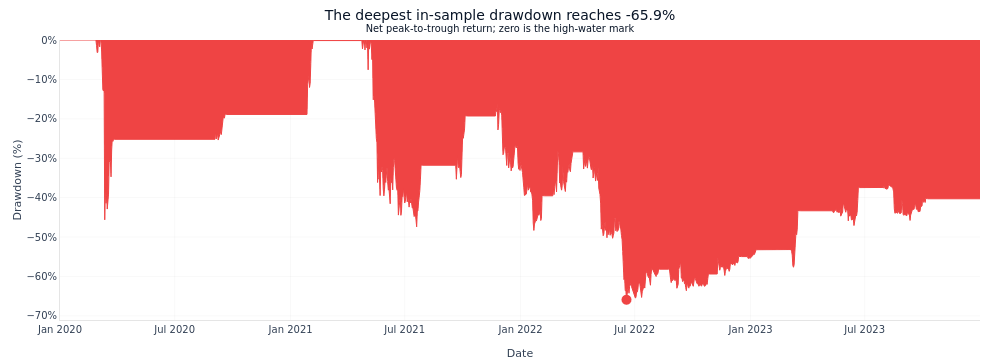

In [29]:
fig = plot_drawdown_underwater(analysis=analysis_net)
fig.data[0].line.color = COLORS["negative"]
fig.data[0].fillcolor = COLORS["negative"]
fig.data[0].opacity = 0.3
fig.data[1].marker.color = COLORS["negative"]
fig.update_layout(
    title=(
        f"The deepest in-sample drawdown reaches {metrics_net.max_drawdown:.1%}"
        "<br><sup>Net peak-to-trough return; zero is the high-water mark</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=360,
)
fig.show()

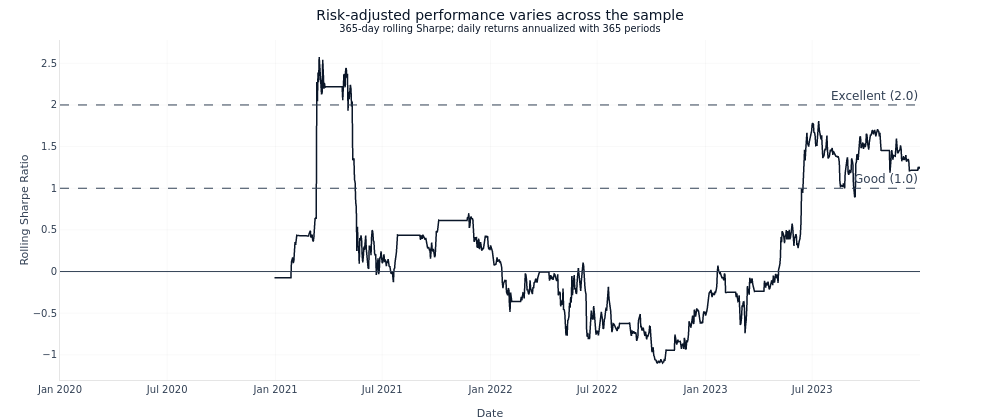

In [30]:
rolling_window = 365
rolling = analysis_net.compute_rolling_metrics(windows=[rolling_window], metrics=["sharpe"])
fig = plot_rolling_sharpe(rolling_result=rolling)
fig.data[0].line.color = COLORS["blue"]
for shape in fig.layout.shapes:
    shape.line.color = COLORS["neutral"]
for annotation in fig.layout.annotations:
    annotation.font.color = COLORS["neutral"]
fig.update_layout(
    title=(
        "Risk-adjusted performance varies across the sample"
        f"<br><sup>{rolling_window}-day rolling Sharpe; daily returns annualized with 365 periods</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Rolling Sharpe Ratio",
    height=420,
)
fig.show()

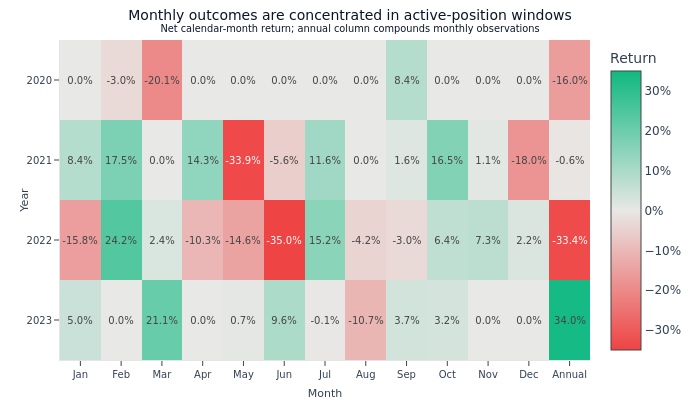

In [31]:
fig = plot_monthly_returns_heatmap(analysis_net)
fig.data[0].colorscale = ml4t_diverging()
fig.update_layout(
    title=(
        "Monthly outcomes are concentrated in active-position windows"
        "<br><sup>Net calendar-month return; annual column compounds monthly observations</sup>"
    ),
    xaxis_title="Month",
    yaxis_title="Year",
)
fig.show()

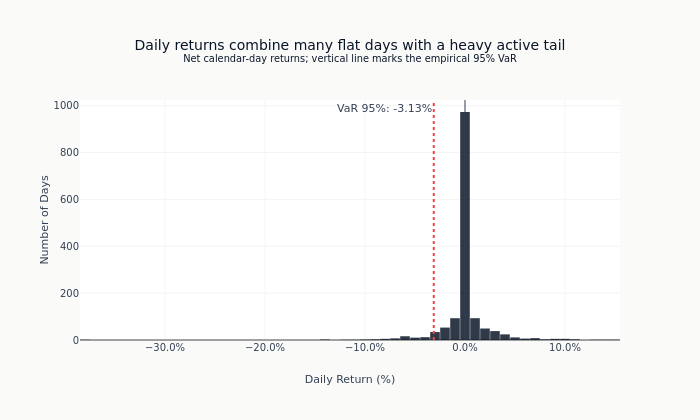

In [32]:
fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=daily_returns["net_return"].to_list(),
        nbinsx=60,
        name="Daily returns",
        marker_color=COLORS["blue"],
        opacity=0.85,
        hovertemplate="Return: %{x:.2%}<br>Count: %{y}<extra></extra>",
    )
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
fig.add_vline(
    x=dist.var_95,
    line_color=COLORS["negative"],
    line_dash="dot",
    annotation_text=f"VaR 95%: {dist.var_95:.2%}",
    annotation_position="top left",
)
fig.update_layout(
    title=(
        "Daily returns combine many flat days with a heavy active tail"
        "<br><sup>Net calendar-day returns; vertical line marks the empirical 95% VaR</sup>"
    ),
    xaxis_title="Daily Return (%)",
    yaxis_title="Number of Days",
    xaxis_tickformat=".1%",
    bargap=0.04,
    height=420,
)
fig.show()

## 8. Standard Report

A compact report keeps portfolio path, benchmark relation, implementation, and trading behavior
distinct. Exact values are assembled from the freshly computed objects rather than copied into
markdown.

In [33]:
report = {
    "Annual return (gross)": f"{metrics_gross.annual_return:.2%}",
    "Annual return (net)": f"{metrics_net.annual_return:.2%}",
    "Annual volatility (net)": f"{metrics_net.annual_volatility:.2%}",
    "Sharpe ratio (net)": f"{metrics_net.sharpe_ratio:.2f}",
    "Sortino ratio (net)": f"{metrics_net.sortino_ratio:.2f}",
    "Maximum drawdown": f"{metrics_net.max_drawdown:.2%}",
    "Maximum drawdown duration": f"{dd_result.max_duration_days} days",
    "Beta vs buy-and-hold": f"{metrics_net.beta:.2f}",
    "Closed round trips": str(analyzer.num_trades),
    "Open trades at sample end": str(len(open_trades)),
    "Win rate": f"{analyzer.win_rate:.1%}",
    "Annual one-way turnover": f"{annual_turnover:.1%}",
    "Mean gross exposure": f"{exposure_df['gross_exposure_pct'].mean():.1%}",
    "Observed one-way cost": f"{observed_cost_bps:.1f} bps",
}
report_df = pl.DataFrame({"metric": list(report), "value": list(report.values())})
display(report_df)

metric,value
str,str
"""Annual return (gross)""","""-2.91%"""
"""Annual return (net)""","""-7.08%"""
"""Annual volatility (net)""","""46.78%"""
"""Sharpe ratio (net)""","""0.09"""
"""Sortino ratio (net)""","""0.06"""
…,…
"""Open trades at sample end""","""0"""
"""Win rate""","""57.1%"""
"""Annual one-way turnover""","""661.1%"""


## Key Takeaways

1. **Protocol is part of the result.** The RSI definition, warmup, fractional target sizing,
   crypto calendar, and next-open fills match `04_single_asset_ml4t_backtest` exactly.
2. **Alignment precedes attribution.** Strategy, gross, and benchmark returns are joined one-to-one
   by date before benchmark-relative statistics cross an array-based API boundary.
3. **Portfolio and trade evidence answer different questions.** Equity includes open exposure;
   win rate, payoff, and MFE/MAE use only completed round trips.
4. **Costs need a single accounting identity.** Reference-price P&L subtracts commission and
   slippage once; break-even cost uses one-way fill notional and elapsed calendar time.
5. **The report is descriptive.** Benchmark, exposure, drawdown, and tail evidence characterize
   this configured sample; they do not establish out-of-sample persistence or optimized exits.

**Next**: `10_regime_backtest_analysis` examines how reported performance varies across market
states. Section 16.5 discusses metric interpretation and practitioner thresholds.